# Week 7：XGBoost 的正则化与早停

目标：理解 XGBoost 如何控制过拟合，并用验证集让模型在合适的时机停止增加树。

## 1. 正则化：给复杂模型加成本

XGBoost 不只追求训练误差小，还会对复杂的树施加惩罚。概念上可以写成：

$$
\text{目标} = \text{训练损失} + \lambda \sum_j w_j^2 + \gamma T
$$

其中 `w_j` 是叶子节点的预测权重，`T` 是叶子节点数量。你需要理解各项的作用，不要求现在推导它。

- `reg_lambda` 对应上式的 `lambda`：越大，越限制叶子权重不要过大。
- `gamma`：一次切分带来的收益必须足够大才允许切分；越大，树越保守。
- `min_child_weight`：子节点需要有足够的样本“重量”才能继续分裂；越大，树越不容易长出只服务少数样本的分支。

## 2. 早停：验证集不再进步就停止

给模型一个较大的树数量上限，例如 1000。每增加一棵树，都观察验证集的 `logloss`。如果连续若干轮没有改善，就停止训练。

这就是 **early stopping（早停）**。它不靠猜应该训练多少棵树，而是让验证结果决定实际使用多少棵。

In [1]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data
y = dataset.target

# 先留出最终测试集；本节不查看它。
X_develop, X_test, y_develop, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 再从开发数据中划出 early stopping 专用验证集。
X_train, X_val, y_train, y_val = train_test_split(
    X_develop, y_develop, test_size=0.20, random_state=42, stratify=y_develop
)

In [3]:
model = XGBClassifier(
    n_estimators=1000,          # 上限，而非一定训练 1000 棵
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    gamma=0.0,
    min_child_weight=1,
    early_stopping_rounds=30,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

val_pred = model.predict(X_val)
print(f'实际使用的最佳树数量：{model.best_iteration + 1}')
print(f'验证集准确率：{accuracy_score(y_val, val_pred):.3f}')

实际使用的最佳树数量：302
验证集准确率：0.956


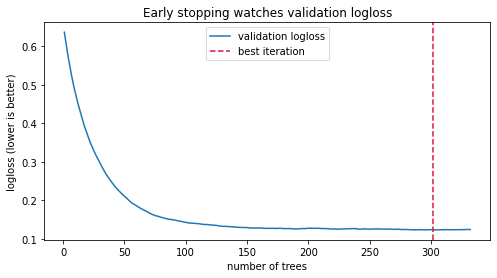

In [4]:
history = model.evals_result()
val_logloss = history['validation_0']['logloss']

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(val_logloss) + 1), val_logloss, label='validation logloss')
plt.axvline(model.best_iteration + 1, color='crimson', linestyle='--', label='best iteration')
plt.xlabel('number of trees')
plt.ylabel('logloss (lower is better)')
plt.title('Early stopping watches validation logloss')
plt.legend()
plt.show()

## 3. 本节如何判断

- 红线左侧：不断加树，验证损失总体在变好。
- 红线附近：验证损失达到最好位置。
- 红线右侧：连续 30 轮没有更好结果，因此停止。

思考题：`n_estimators=1000` 在这里是最终一定会训练 1000 棵树吗？为什么？